In [110]:
import networkx as nx
import matplotlib.pyplot as plt
from network_funcs import S2_graph_definite_N, plot_graph_on_sphere
import numpy as np
import random

In [39]:
def classifying_ent_QKD(G):
    degrees_QKD = dict(G.degree())
    node_size = [d for d in degrees_QKD.values()]
    colors = []
    for node in G.nodes():
        if degrees_QKD[node] == 1: # Edges
            colors.append('yellow')
        elif degrees_QKD[node] == 2: # Repeater
            colors.append('blue')
        else:
            colors.append('red') # Switch
    return node_size, colors

# Barabási-Albert (BA) Model
The BA model generates scale-free networks using a preferential attachment mechanism.

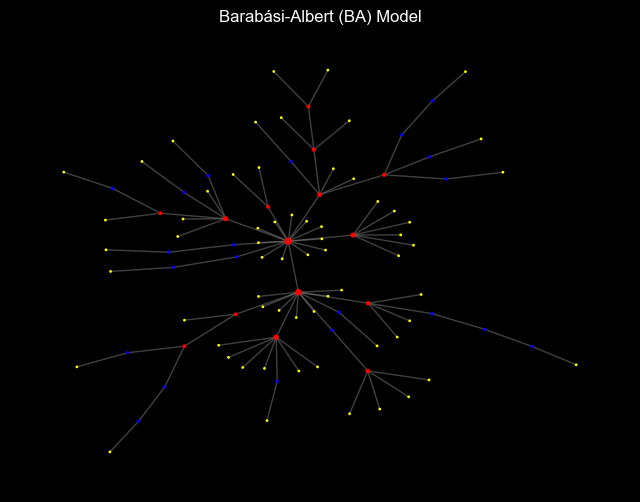

In [164]:
G = nx.barabasi_albert_graph(100, 1)  # 100 nodes, each new node attaches to 3 existing nodes
node_size, colors = classifying_ent_QKD(G)
pos = nx.kamada_kawai_layout(G)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G,pos,node_size=node_size,node_color=colors)
nx.draw_networkx_edges(G,pos,alpha=0.5, edge_color='gray')
plt.title("Barabási-Albert (BA) Model")
plt.axis('off')
plt.savefig("BA_model.pdf")
plt.show()

# Extended Barabási-Albert (EBA) Model
The EBA model extends the BA model by allowing for additional parameters that control the attachment process, such as the probability of adding edges between existing nodes.

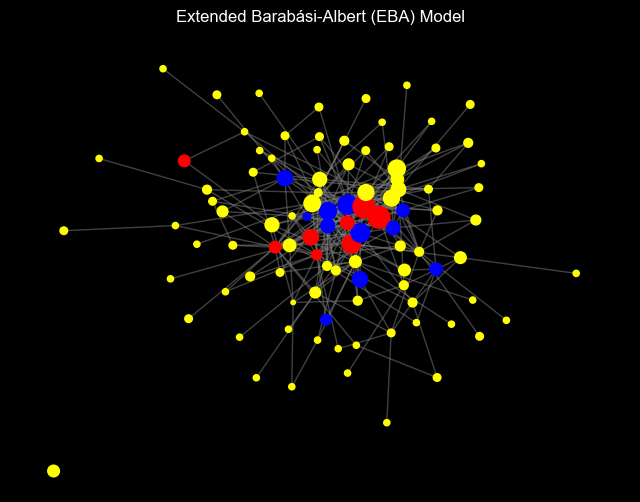

In [76]:
G_EBA = nx.extended_barabasi_albert_graph(100, 1, 0.6, 0.1)  # 100 nodes, m=2, p=0.5
node_size, colors = classifying_ent_QKD(G)
pos_EBA = nx.spring_layout(G_EBA, k=0.25)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_EBA, pos_EBA, node_size=node_size_EBA, node_color=colors)
nx.draw_networkx_edges(G_EBA, pos_EBA, alpha=0.5, edge_color='gray')
plt.title("Extended Barabási-Albert (EBA) Model")
plt.axis('off')
plt.savefig("EBA_model.pdf")
plt.show()

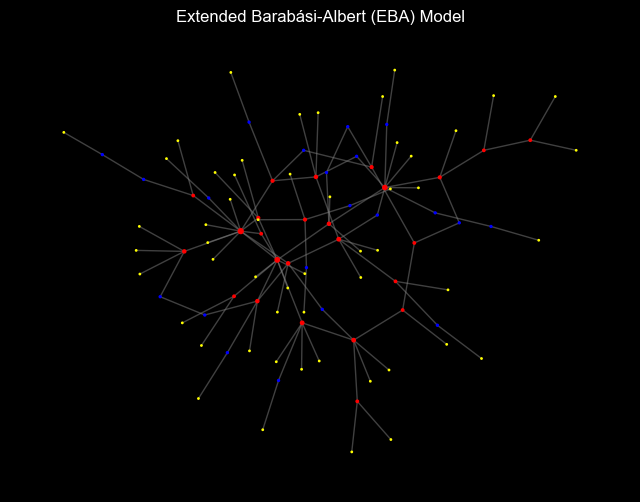

In [102]:
G_EBA = nx.extended_barabasi_albert_graph(100, 1, 0.1, 0.1)  # 100 nodes, m=2, p=0.5
node_size, colors = classifying_ent_QKD(G_EBA)
pos_EBA = nx.kamada_kawai_layout(G_EBA)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_EBA, pos_EBA, node_size=node_size, node_color=colors)
nx.draw_networkx_edges(G_EBA, pos_EBA, alpha=0.5, edge_color='gray')
plt.title("Extended Barabási-Albert (EBA) Model")
plt.axis('off')
plt.savefig("EBA_model_kamada.png")
plt.show()

In [43]:
# Define the parameter sets for the Extended BA model
# m=1 (base connection), p (add edge prob), q (rewire edge prob)
params = [
    {"m": 1, "p": 0.05, "q": 0.05, "filename": "Extended_model_baseline.pdf", "title": "Baseline (p=0.05, q=0.05)"},
    {"m": 1, "p": 0.30, "q": 0.05, "filename": "Extended_model_mesh.pdf",     "title": "Resilient Mesh (p=0.30)"},
    {"m": 1, "p": 0.05, "q": 0.30, "filename": "Extended_model_hyper.pdf",    "title": "Hyper-Centralised (q=0.30)"}
]

for param in params:
    # 1. Generate Graph
    G = nx.extended_barabasi_albert_graph(n=100, m=param["m"], p=param["p"], q=param["q"], seed=42)

    node_size, colors = classifying_ent_QKD(G)

    # 3. Plot and Save
    plt.figure(figsize=(8, 6))

    # Kamada-Kawai keeps the spatial Core-Edge separation consistent with your Dual BA plots
    pos = nx.kamada_kawai_layout(G)

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=node_size, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(param["filename"], format="pdf", bbox_inches="tight")
    plt.close()

# Dual Barabási-Albert (EBA) Model
The Dual Barabási-Albert model is a variation of the BA model that incorporates two different attachment mechanisms, allowing for more complex network structures. It can be used to model networks where nodes have different types of connections or where the attachment process is influenced by multiple factors.

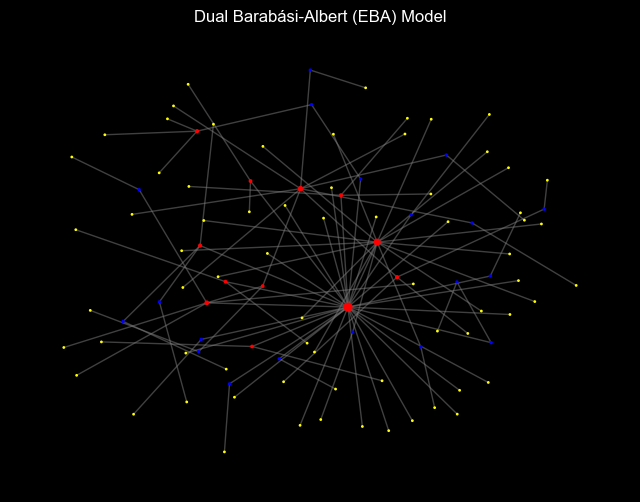

In [85]:
G_BA2 = nx.dual_barabasi_albert_graph(100, 8, 1, 0.01)  # 100 nodes, m1=2, m2=3, p=0.1
node_size, colors = classifying_ent_QKD(G_BA2)
pos_BA2 = nx.spring_layout(G_BA2, k=0.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_BA2, pos_BA2, node_size=node_size, node_color=colors)
nx.draw_networkx_edges(G_BA2, pos_BA2, alpha=0.5, edge_color='gray')
plt.title("Dual Barabási-Albert (EBA) Model")
plt.axis('off')
plt.savefig("Dual_model.pdf")
plt.show()

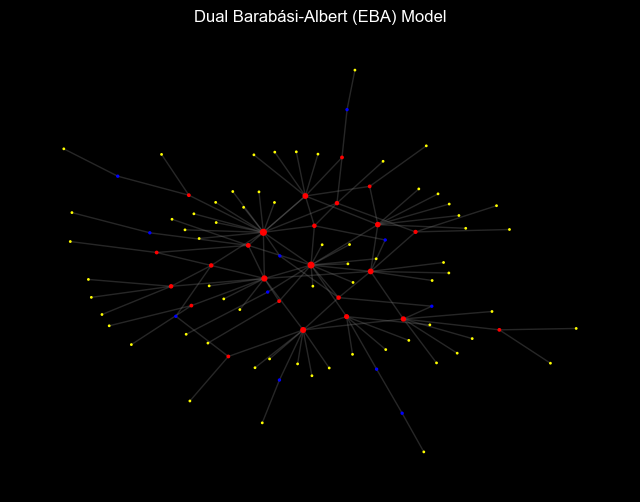

In [149]:
G_BA2 = nx.dual_barabasi_albert_graph(100, 5, 1, 0.05)  # 100 nodes, m1=2, m2=3, p=0.5
node_size, colors = classifying_ent_QKD(G_BA2)
pos_BA2 = nx.kamada_kawai_layout(G_BA2)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_BA2, pos_BA2, node_size=node_size, node_color=colors)
nx.draw_networkx_edges(G_BA2, pos_BA2, alpha=0.3, edge_color='gray')
plt.title("Dual Barabási-Albert (EBA) Model")
plt.axis('off')
plt.savefig("Dual_model_Kamada.png")
plt.show()

In [150]:
def inject_repeater_chains(G, hub_threshold=4, min_repeaters=2, max_repeaters=4, skip_probability=0.25):
    """
    Subdivides edges between high-degree hubs by injecting chains of repeater nodes.

    Parameters:
    - G: The NetworkX graph (e.g., your Dual-BA graph)
    - hub_threshold: Nodes with this degree or higher are considered "Switches"
    - min/max_repeaters: The random number of repeaters to inject in a chain
    """

    # We need to assign new unique IDs to the repeater nodes we create.
    # We'll start counting from the highest existing node ID + 1.
    next_new_node_id = max(G.nodes()) + 1

    for u, v in list(G.edges()):

        # Are BOTH nodes switches?
        if G.degree(u) >= hub_threshold and G.degree(v) >= hub_threshold:

            if random.random() < skip_probability:
                continue # Skips the rest of the loop and leaves the edge intact!

            G.remove_edge(u, v)

            # Decide how many repeaters to put in this specific chain
            num_repeaters = random.randint(min_repeaters, max_repeaters)

            previous_node = u

            for _ in range(num_repeaters):
                current_repeater = next_new_node_id

                G.add_node(current_repeater, type='repeater')

                # Link it to the previous node in the chain
                G.add_edge(previous_node, current_repeater)

                # Move the pointers forward
                previous_node = current_repeater
                next_new_node_id += 1

            # Finally, connect the very last repeater in the chain to switch 'v'
            G.add_edge(previous_node, v)

    return G

In [151]:
G_original =G_BA2.copy()
G_BA2 = inject_repeater_chains(G_BA2, hub_threshold=6, min_repeaters=1, max_repeaters=3)

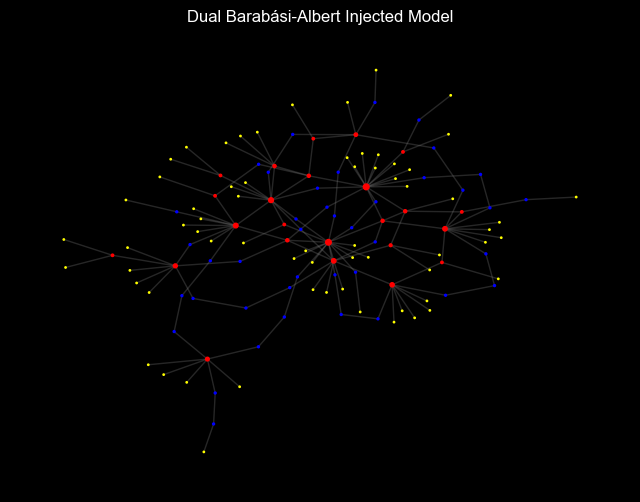

In [152]:
node_size, colors = classifying_ent_QKD(G_BA2)
pos_BA2 = nx.kamada_kawai_layout(G_BA2)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_BA2, pos_BA2, node_size=node_size, node_color=colors)
nx.draw_networkx_edges(G_BA2, pos_BA2, alpha=0.3, edge_color='gray')
plt.title("Dual Barabási-Albert Injected Model")
plt.axis('off')
plt.savefig("Dual_model_Kamada_injected.png")
plt.show()

In [90]:

# Define the parameter sets we want to test
params = [
    {"m1": 5,  "m2": 1, "p": 0.05, "filename": "Dual_model_baseline.pdf", "title": "Baseline (m1=5, p=0.05)"},
    {"m1": 15, "m2": 1, "p": 0.05, "filename": "Dual_model_heavy.pdf",    "title": "Heavy Backbone (m1=15, p=0.05)"},
    {"m1": 5,  "m2": 1, "p": 0.15, "filename": "Dual_model_dist.pdf",     "title": "Distributed Core (m1=5, p=0.15)"}
]

for param in params:
    # 1. Generate Graph
    G = nx.dual_barabasi_albert_graph(n=100, m1=param["m1"], m2=param["m2"], p=param["p"], seed=42)

    node_size, colors = classifying_ent_QKD(G)

    # 3. Plot and Save
    plt.figure(figsize=(8, 6))
    pos = nx.kamada_kawai_layout(G)

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=node_size, edgecolors='white')
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(param["filename"], format="pdf", bbox_inches="tight")
    plt.close() # Close figure to free memory

# Watts-Strogatz (WS) Model
The WS model generates small-world networks by rewiring edges with a certain probability.

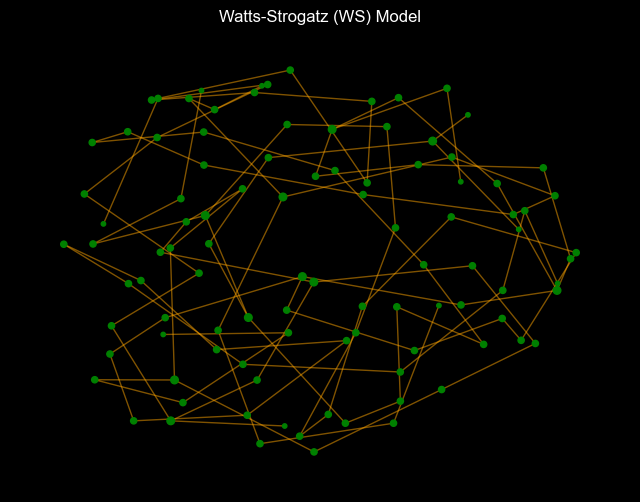

In [109]:
G_ws = nx.watts_strogatz_graph(100, 2, 0.1)  # 100 nodes, each node connected to 4 neighbors, rewiring probability 0.1
degrees_ws = dict(G_ws.degree())
node_size_ws = [v * 10 for v in degrees_ws.values()]  # Scale
pos_ws = nx.spring_layout(G_ws, k=0.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_ws, pos_ws, node_size=node_size_ws, node_color='green')
nx.draw_networkx_edges(G_ws, pos_ws, alpha=0.5, edge_color='orange')
plt.title("Watts-Strogatz (WS) Model")
plt.axis('off')
plt.savefig("WS_model.pdf")
plt.show()

# Luca's S2 Graph Model
Luca's S2 graph model generates networks based on points distributed on a sphere, with edges formed based on a distance threshold.

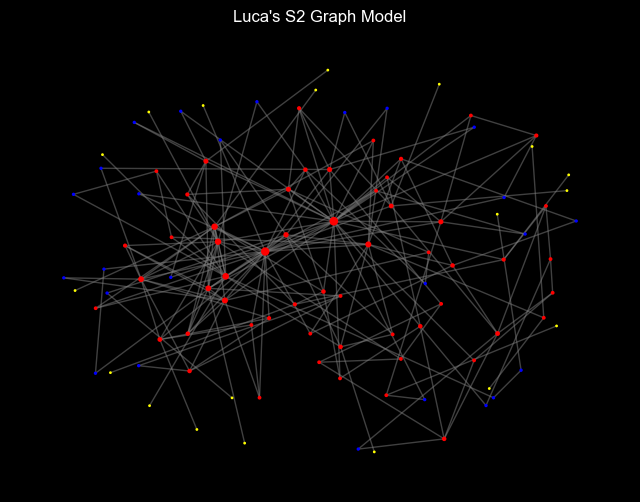

In [105]:
A, _, coords = S2_graph_definite_N(100, 2.6, 0.0233, return_coords=True)
G_s2 = nx.from_numpy_array(A)  # Convert adjacency matrix to graph
node_size, colors = classifying_ent_QKD(G_s2)
pos_s2 = nx.spring_layout(G_s2, k=0.7)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_s2, pos_s2, node_size=node_size, node_color=colors)
nx.draw_networkx_edges(G_s2, pos_s2, alpha=0.5, edge_color='gray')
plt.title("Luca's S2 Graph Model")
plt.axis('off')
plt.savefig("S2_model_sping.pdf")
plt.show()

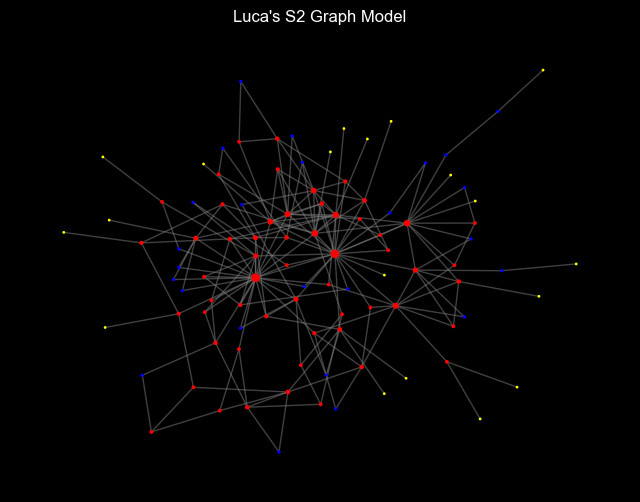

In [106]:
pos_s2 = nx.kamada_kawai_layout(G_s2)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_s2, pos_s2, node_size=node_size, node_color=colors)
nx.draw_networkx_edges(G_s2, pos_s2, alpha=0.5, edge_color='gray')
plt.title("Luca's S2 Graph Model")
plt.axis('off')
plt.savefig("S2_model_kamada.png")
plt.show()

## Adding end users to S2

In [165]:
import networkx as nx
import numpy as np
import random

def add_end_users_to_s2(G_s2, original_coords, num_end_users, spread=0.05):
    """
    Attaches degree-1 end users to an S2 graph using Preferential Attachment,
    and clusters them geometrically around their hubs on the sphere.

    Parameters:
    - G_s2: The base networkx graph from the S2 model
    - original_coords: The (N, 3) numpy array of 3D coordinates from the S2 model
    - num_end_users: How many end users to add
    - spread: How far away the users spawn from the hub (smaller = tighter clusters)
    """
    # 1. Setup the safe copies
    G = G_s2.copy()
    nx.set_node_attributes(G, 'switch', 'type') # Label original nodes

    # Convert coords array to a list so we can append to it
    all_coords = list(original_coords)

    # Get the current nodes and their degrees for the PA lottery
    hubs = list(G.nodes())
    hub_degrees = [G.degree(n) for n in hubs]

    next_node_id = len(hubs)

    # 2. Add the end users
    for _ in range(num_end_users):
        # Preferential Attachment: Pick a hub (higher degree = higher chance)
        chosen_hub = random.choices(hubs, weights=hub_degrees, k=1)[0]

        # Retrieve the 3D vector of the chosen hub
        hub_vec = all_coords[chosen_hub]

        # Geometry: Add random noise to simulate placing the user near the hub
        noise = np.random.uniform(-spread, spread, 3)
        user_vec = hub_vec + noise

        # Normalize the vector so it sits perfectly on the surface of the radius-1 sphere
        user_vec = user_vec / np.linalg.norm(user_vec)

        # 3. Update the Graph and Coordinates
        G.add_node(next_node_id, type='end')
        G.add_edge(chosen_hub, next_node_id)
        all_coords.append(user_vec)

        # Give the chosen hub an extra "lottery ticket" because its degree just went up
        hub_degrees[chosen_hub] += 1

        next_node_id += 1

    # Return the new graph and the updated numpy array of coordinates
    return G, np.array(all_coords)

In [166]:
# 1. Generate the core backbone using Lucas's code (e.g., 50 switches)
A, Dists, s2_coords = S2_graph_definite_N(50, 2.6, 0.0233, return_coords=True)
G_core = nx.from_numpy_array(A)

# 2. Add 200 end users geometrically attached to the hubs
G_final, final_coords = add_end_users_to_s2(G_core, s2_coords, num_end_users=200)

# 3. Project it and plot it! (Using the projection script we wrote earlier)
x_2d, y_2d = _sphere_to_2d(final_coords, scale_km=100)
pos_dict = {i: (x_2d[i], y_2d[i]) for i in range(len(x_2d))}

# ... plot with nx.draw_networkx_nodes ...

In [52]:
plot_graph_on_sphere(coords, A, R=1, filename="S2_model_sphere.pdf")

In [54]:
def _sphere_to_2d(coords, scale_km = 1):
    """
    Equirectangular projection of unit-sphere coords to km.

    Parameters
    ----------
    coords   : np.ndarray (N, 3)
    scale_km : float   km per radian

    Returns
    -------
    x, y : np.ndarray (N,)   positions in km
    """
    lat = np.arcsin(np.clip(coords[:, 2], -1, 1))
    lon = np.arctan2(coords[:, 1], coords[:, 0])
    return lon * scale_km, lat * scale_km



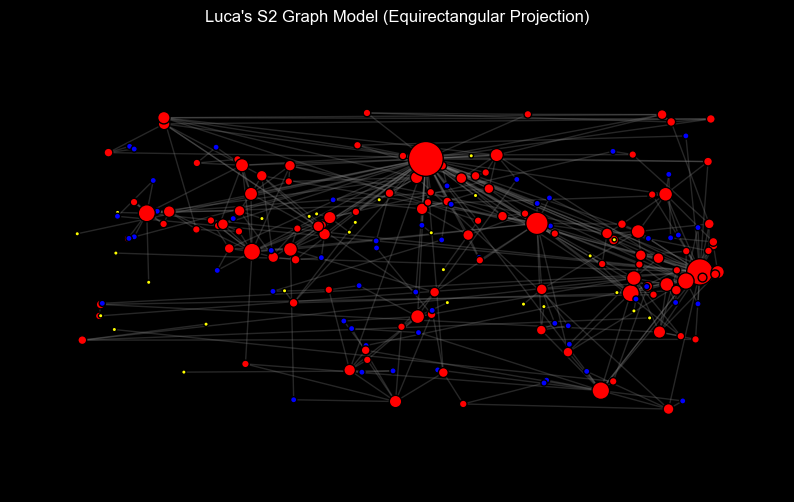

In [57]:
A, _, coords = S2_graph_definite_N(200, 2.6, 0.0233, return_coords=True)
G_s2 = nx.from_numpy_array(A)

# --- 3. Process Coordinates ---
# Project the 3D spherical coordinates to 2D
x_2d, y_2d = _sphere_to_2d(coords, scale_km=100) # Adjust scale_km as needed

# Create a position dictionary for NetworkX: {node_id: (x, y)}
pos_s2 = {i: (x_2d[i], y_2d[i]) for i in range(len(x_2d))}

# --- 4. Process Styling ---
node_size, colors = classifying_ent_QKD(G_s2)

# NetworkX node sizes are in points^2. Raw degrees (1, 2, 3...) will be microscopic.
# We scale them up so they are clearly visible.
scaled_sizes = [s * 10 for s in node_size]

# --- 5. Plotting ---
plt.figure(figsize=(10, 6))

# Draw nodes and edges using the custom projected positions
nx.draw_networkx_nodes(G_s2, pos_s2, node_size=scaled_sizes, node_color=colors, edgecolors='black')
nx.draw_networkx_edges(G_s2, pos_s2, alpha=0.3, edge_color='gray')

# Formatting
plt.title("Luca's S2 Graph Model (Equirectangular Projection)")
plt.axis('equal') # Prevents distortion of the coordinates
plt.axis('off')

# Save and Show
plt.savefig("S2_model_projection.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Start Graph
The Start graph is a simple graph structure that serves as a baseline for comparison with more complex network models. It typically consists of a small number of nodes and edges, often arranged in a regular pattern, such as a ring or a grid.

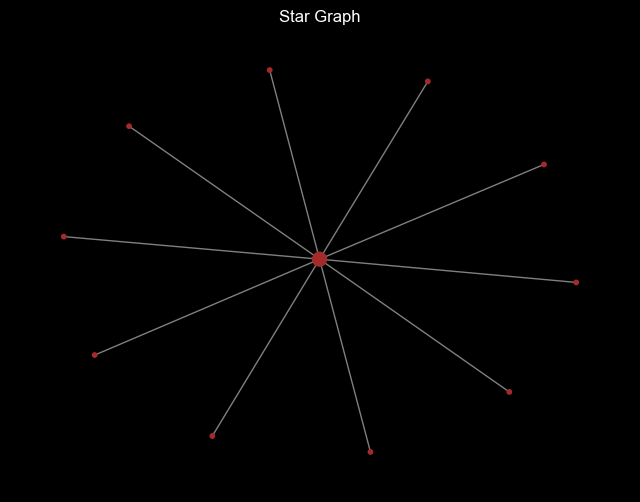

In [17]:
G_star = nx.star_graph(10)  # Create a star graph with 10 peripheral nodes
degrees_star = dict(G_star.degree())
node_size_star = [v * 10 for v in degrees_star.values()]  # Scale node size by degree
pos_star = nx.spring_layout(G_star, k=0.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_star, pos_star, node_size=node_size_star, node_color='brown')
nx.draw_networkx_edges(G_star, pos_star, alpha=0.5, edge_color='white')
plt.title("Star Graph")
plt.axis('off')
plt.savefig("Star_graph.pdf")
plt.show()

# Stochastic Block Model (SBM)
The SBM is a generative model for random graphs that can produce community structures by defining blocks of nodes with different probabilities of connection.

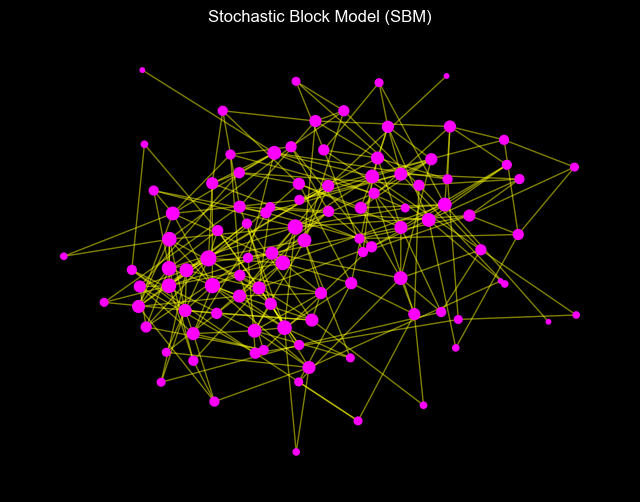

In [16]:
G_SBM = nx.stochastic_block_model([50, 50], [[0.1, 0.01], [0.01, 0.1]])  # 2 blocks of 50 nodes each, with different connection probabilities
degrees_SBM = dict(G_SBM.degree())
node_size_SBM = [v * 10 for v in degrees_SBM.values()] # Scale node size by degree
pos_SBM = nx.spring_layout(G_SBM, k=0.5)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_SBM, pos_SBM, node_size=node_size_SBM, node_color='magenta')
nx.draw_networkx_edges(G_SBM, pos_SBM, alpha=0.5, edge_color='yellow')
plt.title("Stochastic Block Model (SBM)")
plt.axis('off')
plt.savefig("SBM_model.pdf")
plt.show()

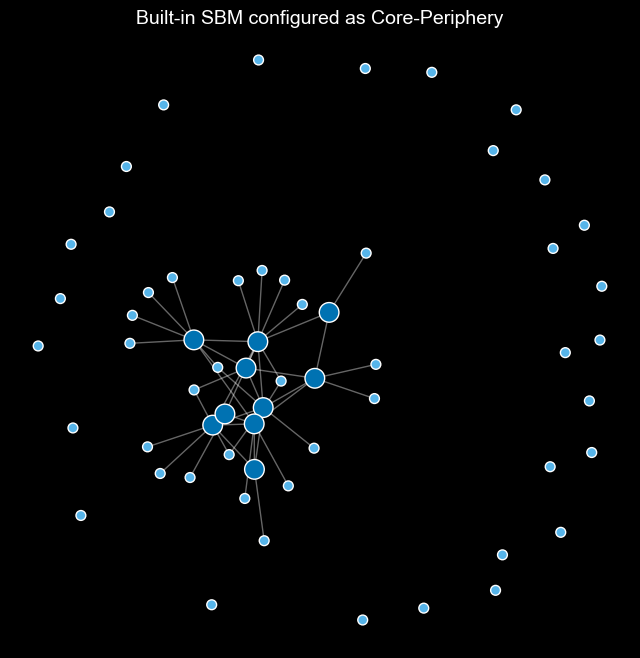

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define the sizes of the 3 blocks
# 10 backbone routers, 25 users on one side, 25 users on the other
sizes = [10, 25, 25]

# 2. Define the Probability Matrix (This is the secret sauce!)
# p_core_core = 0.4  (Dense inner mesh)
# p_user_user = 0.0  (Users NEVER connect to other users)
# p_core_user = 0.05 (Users connect sparsely to the core, acting like starbursts)

probs = [
    [0.40, 0.05, 0.05],  # Block 0 (Core) connections
    [0.05, 0.00, 0.00],  # Block 1 (Users A) connections
    [0.05, 0.00, 0.00]   # Block 2 (Users B) connections
]

# 3. Generate the built-in SBM
G_sbm = nx.stochastic_block_model(sizes, probs, seed=42)

# 4. Plot it to see the Core-Periphery shape
plt.figure(figsize=(8, 8))
plt.title("Built-in SBM configured as Core-Periphery", fontsize=14)

# Spring layout works well here because the "zero probability" users
# will naturally be pushed to the outside edges!
pos = nx.spring_layout(G_sbm, k=0.3)

# Color the Core nodes dark blue, and the User nodes light blue
colors = ['#0072B2']*10 + ['#56B4E9']*25 + ['#56B4E9']*25
sizes_list = [200]*10 + [50]*25 + [50]*25

nx.draw_networkx_nodes(G_sbm, pos, node_color=colors, node_size=sizes_list, edgecolors='white')
nx.draw_networkx_edges(G_sbm, pos, alpha=0.4, edge_color='white')

plt.axis('off')
plt.show()

# Bianconi-Barabási (BB) Model
The BB model is an extension of the BA model that incorporates node fitness, allowing for a more realistic representation of networks where nodes have varying levels of attractiveness for new connections.

In [96]:

def generate_bb_model(n_nodes, m_edges, fitness_dict, seed=42):
    """Custom generator for the Bianconi-Barabási Fitness Model."""
    np.random.seed(seed)
    G = nx.complete_graph(m_edges + 1)

    for new_node in range(m_edges + 1, n_nodes):
        degrees = dict(G.degree())
        # The core BB equation: Probability ~ Degree * Fitness
        weights = [degrees[node] * fitness_dict.get(node, 0.1) for node in G.nodes()]
        total_weight = sum(weights)
        probabilities = [w / total_weight for w in weights]

        # Connect to existing nodes based on this probability
        targets = np.random.choice(G.nodes(), size=m_edges, replace=False, p=probabilities)

        G.add_node(new_node)
        for target in targets:
            G.add_edge(new_node, target)

    return G

n = 100
m = 1

# 1. Uniform Fitness (Standard BA)
fit_uniform = {i: 1.0 for i in range(n)}

# 2. Bimodal Fitness (5 Quantum Hubs, 95 End Users)
fit_bimodal = {i: 10.0 if i < 5 else 0.1 for i in range(n)}

# 3. Bose-Einstein Condensation (1 Absolute Monopoly Super-Hub)
fit_condense = {i: 1000.0 if i == 50 else 0.1 for i in range(n)}

scenarios = [
    {"fit": fit_uniform,  "name": "BB_model_uniform.pdf",  "title": "Uniform (Standard BA)"},
    {"fit": fit_bimodal,  "name": "BB_model_bimodal.pdf",  "title": "Bimodal (Core-Edge)"},
    {"fit": fit_condense, "name": "BB_model_condense.pdf", "title": "Bose-Einstein Condensation"}
]

for s in scenarios:
    G = generate_bb_model(n_nodes=n, m_edges=m, fitness_dict=s["fit"])

    # Color based on fitness to show cause-and-effect!
    node_size, colors = classifying_ent_QKD(G)

    plt.figure(figsize=(8, 6))
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=node_size, edgecolors='white')
    nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(s["name"], format="pdf", bbox_inches="tight")
    plt.close()

## Dijkstra algorithm

In [15]:
def brute_force_dijkstra(graph, start_node, target_node):
    """
    Finds the shortest path using pure brute-force Dijkstra (no external libraries).
    """
    # Step 1: Initialise distances and previous nodes
    distances = {node: float('inf') for node in graph}
    distances[start_node] = 0
    previous_nodes = {node: None for node in graph}

    # Keep a simple list of all nodes we haven't checked yet
    unvisited = list(graph.keys())

    # Step 2: The Main Loop
    while unvisited:
        # --- THE BRUTE FORCE PART ---
        # Manually search the unvisited list for the node with the lowest distance
        current_node = None
        current_min_distance = float('inf')

        for node in unvisited:
            if distances[node] < current_min_distance:
                current_min_distance = distances[node]
                current_node = node

        # If the lowest distance is infinity, it means the remaining nodes are completely
        # disconnected from our start node. We can stop searching.
        if current_node is None:
            break

        # If we found our target, we can stop early!
        if current_node == target_node:
            break

        # Step 3: Explore neighbours
        for neighbour, weight in graph[current_node].items():
            # Only check neighbours that haven't been visited yet
            if neighbour in unvisited:
                # Calculate the cost to reach this neighbour
                distance_to_neighbour = distances[current_node] + weight

                # Step 4: Update if we found a better route
                if distance_to_neighbour < distances[neighbour]:
                    distances[neighbour] = distance_to_neighbour
                    previous_nodes[neighbour] = current_node

        # Step 5: Mark the current node as visited by removing it from the list
        unvisited.remove(current_node)

    # --- Step 6: Path Reconstruction ---
    path = []
    current = target_node

    while current is not None:
        path.append(current)
        current = previous_nodes[current]

    path.reverse()

    if len(path) == 1 and start_node != target_node:
        return float('inf'), []

    return distances[target_node], path

# ==========================================
# Example Usage on a Small Network
# ==========================================
quantum_network = {
    'Alice': {'Repeater1': 2, 'Repeater2': 5},
    'Repeater1': {'Alice': 2, 'Repeater2': 1, 'Bob': 6},
    'Repeater2': {'Alice': 5, 'Repeater1': 1, 'Bob': 2},
    'Bob': {'Repeater1': 1, 'Repeater2': 10}
}

cost, routing_path = brute_force_dijkstra(quantum_network, 'Alice', 'Bob')

print(f"Total Path Cost: {cost}")
print(f"Optimal Routing Path: {routing_path}")

Total Path Cost: 5
Optimal Routing Path: ['Alice', 'Repeater1', 'Repeater2', 'Bob']


# Backbone + Preferential attachment



In [144]:
import networkx as nx
import random

def build_scalable_backbone(total_nodes, switch_percentage=0.08):
    """
    Automatically builds a realistic quantum backbone based on the target network size.
    """
    # 1. Calculate how many switches we need (e.g., 8% of 500 = 40 switches)
    num_switches = int(total_nodes * switch_percentage)

    # 2. Build a "Small World" core (Watts-Strogatz is perfect for this)
    # k=4 means each switch connects to roughly 4 other switches.
    # p=0.2 adds 20% randomness to make it look organic like a real map.
    backbone = nx.watts_strogatz_graph(n=num_switches, k=4, p=0.2)

    # Label these core nodes as switches
    nx.set_node_attributes(backbone, 'switch', 'type')

    # 3. Inject the repeaters on the backbone edges (using our logic from earlier)
    next_new_node_id = num_switches

    for u, v in list(backbone.edges()):
        backbone.remove_edge(u, v)

        # Decide randomly to put 1, 2, or 3 repeaters between these switches
        num_repeaters = random.randint(1, 3)
        previous_node = u

        for _ in range(num_repeaters):
            current_repeater = next_new_node_id
            backbone.add_node(current_repeater, type='repeater')
            backbone.add_edge(previous_node, current_repeater)

            previous_node = current_repeater
            next_new_node_id += 1

        backbone.add_edge(previous_node, v)

    return backbone

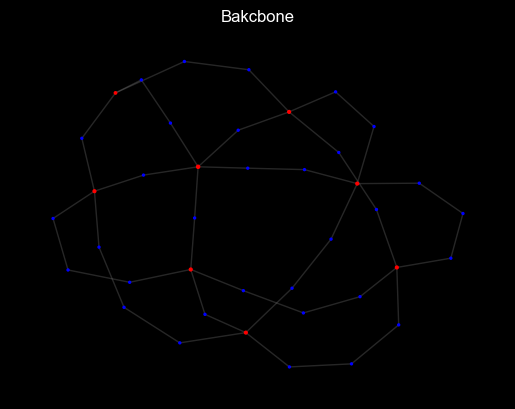

In [155]:

# 1. Generate the smart backbone (it will dynamically size itself based on the 500 target)
my_seed_graph = build_scalable_backbone(total_nodes=100, switch_percentage=0.08)
node_size, colors = classifying_ent_QKD(my_seed_graph)
pos = nx.kamada_kawai_layout(my_seed_graph)
nx.draw_networkx_nodes(my_seed_graph, pos, node_size=node_size, node_color=colors)
nx.draw_networkx_edges(my_seed_graph, pos, alpha=0.3, edge_color='gray')
plt.title("Bakcbone")
plt.axis('off')
plt.savefig("Backbone.png")
plt.show()
# 2. Let the Barabási-Albert algorithm add the remaining End-Users!
# We tell the BA algorithm to stop when the total network reaches 500 nodes.
final_quantum_network = nx.barabasi_albert_graph(n=100, m=1, initial_graph=my_seed_graph)

# (Optional Step 3: Loop through and label any node without a 'type' as an 'end_user',
# then pass it to your coloring function and plot with Kamada-Kawai!)

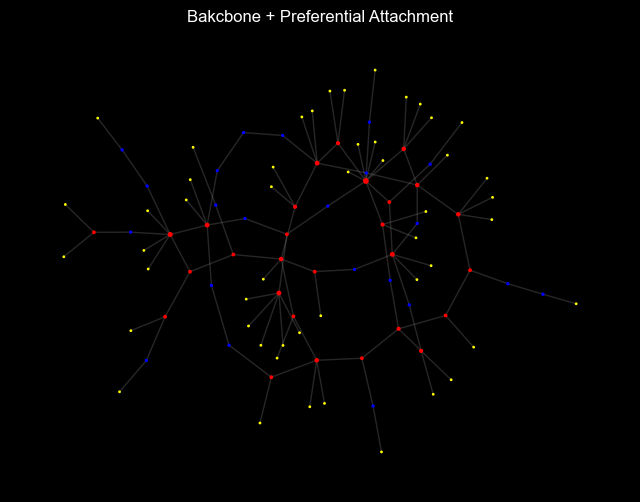

In [148]:
node_size, colors = classifying_ent_QKD(final_quantum_network)
pos = nx.kamada_kawai_layout(final_quantum_network)  # Position nodes using Fruchterman-Reingold force-directed algorithm
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(final_quantum_network, pos, node_size=node_size, node_color=colors)
nx.draw_networkx_edges(final_quantum_network, pos, alpha=0.3, edge_color='gray')
plt.title("Bakcbone + Preferential Attachment")
plt.axis('off')
plt.savefig("Backbone_Pref_Attachment.png")
plt.show()

## Spatial preferential attachment

In [160]:
import networkx as nx
import numpy as np
import random

def spatial_preferential_attachment(n, m=2, alpha=2.0, map_size=1000):
    G = nx.Graph()

    # 1. THE MAP: Pre-calculate random (X, Y) coordinates for everyone
    coords = {i: (random.uniform(0, map_size), random.uniform(0, map_size)) for i in range(n)}

    # Seed the graph with an initial triangle, attaching their coordinates as they spawn
    for i in range(3):
        G.add_node(i, pos=coords[i])
    G.add_edges_from([(0, 1), (1, 2), (2, 0)])

    # 2. THE LOOP: Add the remaining nodes one by one
    for i in range(3, n):
        # Add the new node AND its coordinate attribute simultaneously
        G.add_node(i, pos=coords[i])

        # Get all nodes except the one we just added
        existing_nodes = list(G.nodes())[:-1]

        weights = []
        for j in existing_nodes:
            # Calculate physical distance
            dist = np.sqrt((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2)
            dist = max(dist, 0.001) # Prevent division by zero

            # THE EQUATION: Score = Degree / (Distance^Alpha)
            score = G.degree(j) / (dist ** alpha)
            weights.append(score)

        # 3. THE ROULETTE WHEEL: Pick 'm' unique targets based on the scores
        chosen_targets = set()
        while len(chosen_targets) < m:
            target = random.choices(existing_nodes, weights=weights, k=1)[0]
            chosen_targets.add(target)

        for target in chosen_targets:
            G.add_edge(i, target)

    return G

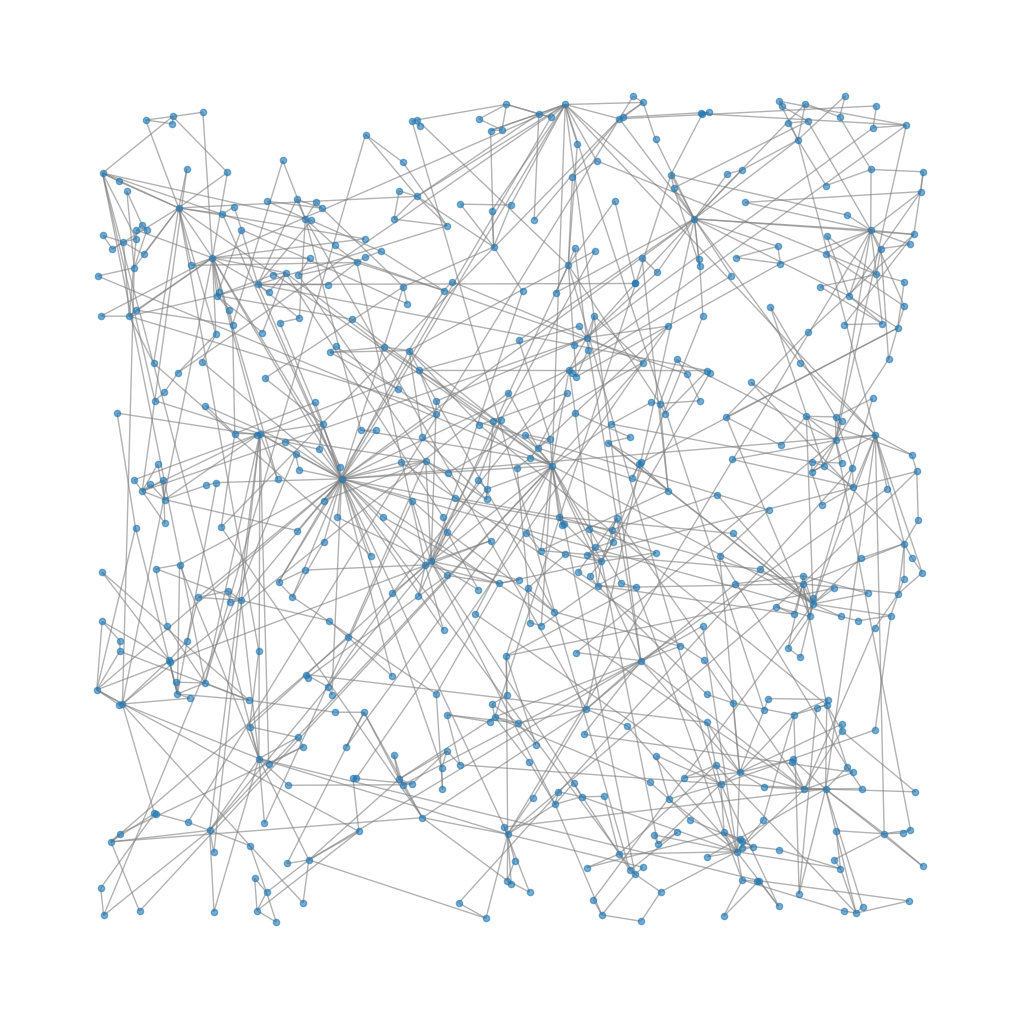

In [161]:
# Generate a 500-node network with a heavy distance penalty (alpha=2.5)
G_spatial = spatial_preferential_attachment(n=500, m=2, alpha=2.5)

# Extract the exact coordinates from the graph
true_positions = nx.get_node_attributes(G_spatial, 'pos')

# Plot it using those exact coordinates!
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
nx.draw(G_spatial, pos=true_positions, node_size=20, alpha=0.6, edge_color="gray")
plt.show()